In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit
import pandas as pd
import numpy as np

# Ajuste a grafica "stopping powers"

A partir de la gráfica adjunta de "stopping Powers" ( dE/dx ) de protones en Silicio, encuentre una relación que
permita obtener el valor de ( dE/dx ) en función de la energía E de los protones.
Puede ser una tabla "E"_vs_"dE/dx" y hacer un ajuste de un polinomio de grado 2 para hallar ( dE/dx ) para
cualquier valor de E

In [2]:
from utilities.ajuste  import ajuste_stopping_power, modelo

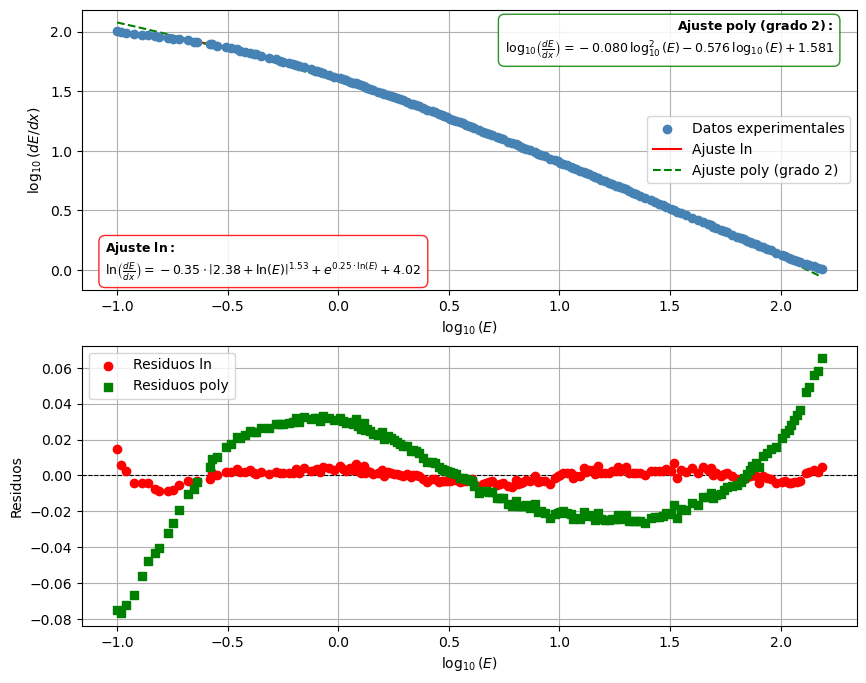

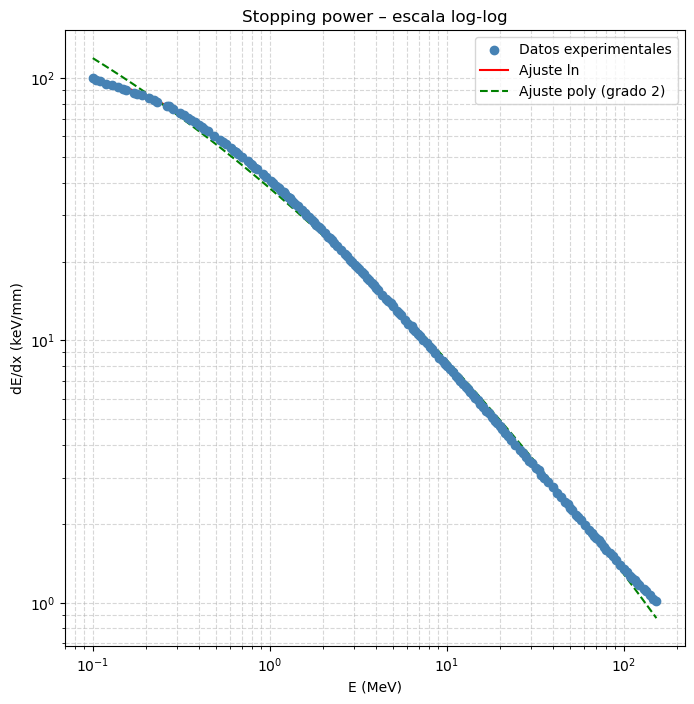

In [3]:
(fig1, fig2), (model_ln, model_poly), (popt, pcov, poly_coef) = ajuste_stopping_power()

los modelos resultan ser, ambos se ajustan muy bien y pese a que los residuales parecen presentar una tendencia periodica esto posiblemente se debe al software que se uso para obtener los datos de las graficas de [1]

ln -> basado en la forma vista en clase por lo que es mas exacto
$$
\ln \left (\frac{dE}{dx}[KeV/mm]\right) = -0.35\cdot |2.38 + \ln(E[MeV])|^{1.53} + e^{0.25\cdot \ln (E[MeV])}+4.02  
$$
y 
poly -> una aproximacion polinomica de grado 2
$$
\log10(\frac{dE}{dx}[KeV/mm]) = -0.088\log10^2(E[MeV])-0.576\log10(E[MeV])+1.581
$$

# Cálculo numérico del alcance de protones en silicio

Realice un cálculo numérico de los protones avanzando en el Silicio por pasos de espesor deltaX muy pequeño:
Se va avanzando en la profundidad X alcanzada por pasos deltaX:
Profundidad X nueva = Profundidad X anterior + deltaX
En esa nueva profundidad X determinamos la energía:
(Energía nueva) = (Energía anterior) – (dE/dx)*deltaX.
El valor de (dE/dx) es el que corresponde a la (Energía anterior).
Guarde en un arreglo el par de datos: {profundidad X actual, deltaE=(dE/dx)*deltaX}
Se repite avanzando en la profundidad X hasta que la (Energía nueva) sea menor o igual a cero.
Cuando se alcance energía cero, o menor, el valor de la profundidad X es el alcance R (range). Dé esto como
respuesta b.

In [9]:
def euler_range(model, E0=100.0, dx=0.01, E_stop=1e-3):
    """Euler simulation of proton slowing down in Si.
    model(E) -> dE/dx [keV/mm],  E in MeV, dx in mm.
    Returns arrays: x [mm], E [MeV], dEdx [keV/mm].
    """
    E, x = E0, 0.0
    x_list, E_list, dEdx_list = [x], [E], []
    while E >= E_stop:
        dEdx  = float(model(np.array([E]))[0])   # keV/mm
        E    -= dEdx * dx                 # convert keV→MeV
        x    += dx
        dEdx_list.append(dEdx)
        x_list.append(x)
        E_list.append(E)
    return np.array(x_list), np.array(E_list), np.array(dEdx_list)


x_ln,   E_ln,   dEdx_ln   = euler_range(model_ln,E_stop=1e-3)
x_poly, E_poly, dEdx_poly = euler_range(model_poly,E_stop=1e-3)
x_ln_E1,   _,   _   = euler_range(model_ln,E_stop=1)
x_poly_E1, _, _ = euler_range(model_poly,E_stop=1)

print(f"depth(0MeV) (ln fit)  : {x_ln[-1]:.4f} mm")
print(f"depth (0MeV) (poly fit): {x_poly[-1]:.4f} mm")

print(f"depth (1MeV) (ln fit)  : {x_ln_E1[-1]:.4f} mm")
print(f"depth (1MeV) (poly fit): {x_poly_E1[-1]:.4f} mm")

depth(0MeV) (ln fit)  : 41.9300 mm
depth (0MeV) (poly fit): 41.8400 mm
depth (1MeV) (ln fit)  : 41.9100 mm
depth (1MeV) (poly fit): 41.8100 mm


No resulta una diferencia significativa entre detener la simulacion en $1MeV$ y $0MeV$ esto resulta asi que en la tabla tomada [1] de valores rangos para protones con $1MeV$ en silicio es de $0.0170mm$ que es mucho mas pequeño que el alcance que se esta teniendo de alrededor de $42mm$ ciertamente entrando en el rango de apreciación del modelo, al comparar ambos modelos ln fit (mas exacto) y el poly fit (mas simple) la diferencia tambien resulta minima mostrando que el modelo polinomial de grado 2 resulta ser un fit valido para estos rangos de energia

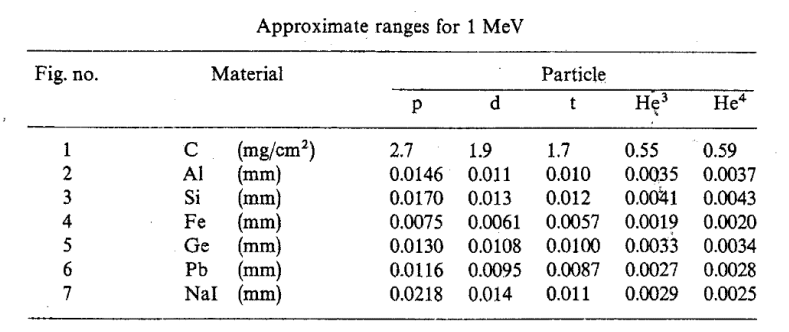

# Comparación teoría con modelo

Compare el resultado de R, obtenido aplicando el cálculo numérico por pasos con lo que muestra la gráfica de
RANGE DIFFERENCE para protones avanzando en Silicio. Comente la exactitud alcanzada con su cálculo
numérico por pasos

utilizando la grafica "range differences for silicon" tomada de [1]

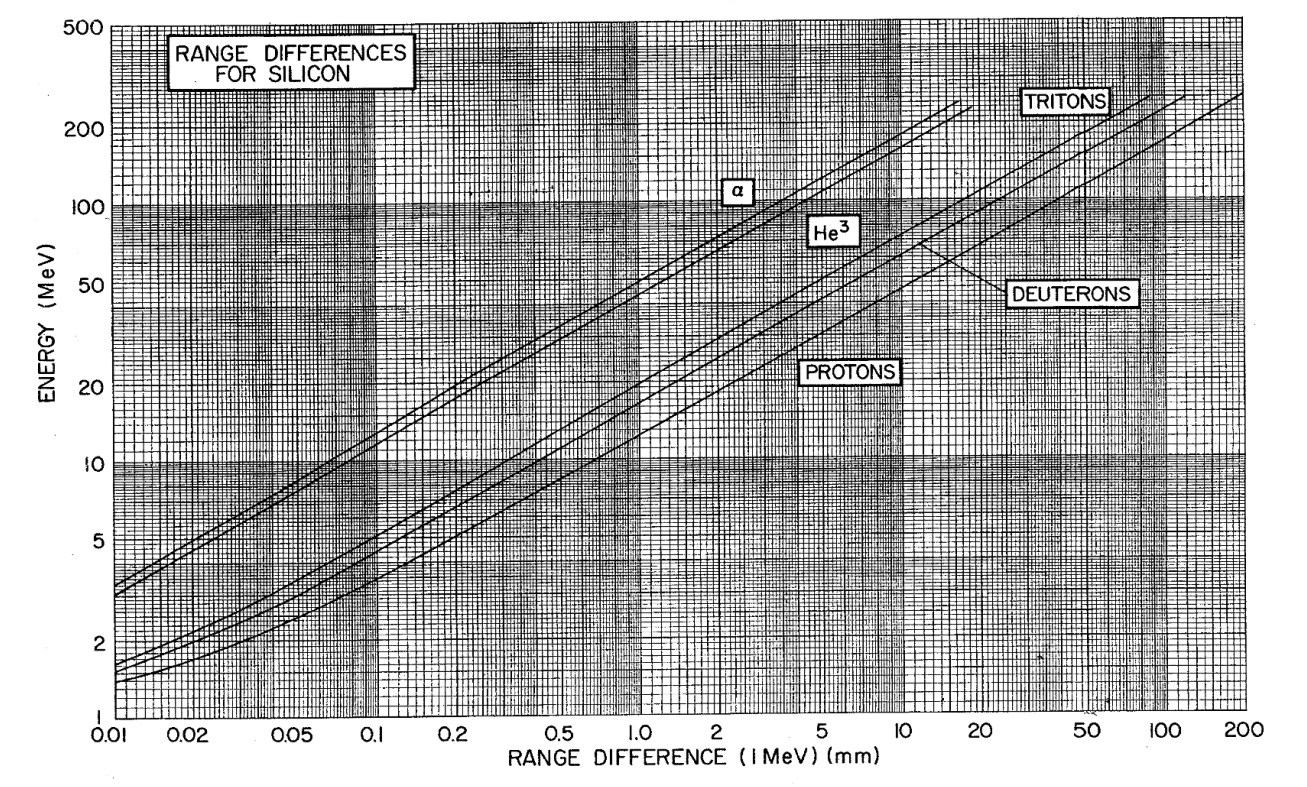

se puede observar que Range teorico es alrededor de $40mm$ lo cual comparado con los resultados del modelo mas exacto y el polinomial de grado 2 de $41.93mm$ y $41.84mm$ respectivamente se puede concluir que se tiene una muy buena aproximacion y con datos mas detallados se podria tener una aun mejor



# Verificacion y Analisis grafico
Realice una gráfica de deltaE vs. X (en el eje vertical el deltaE, en el eje horizontal X). ¿Cómo aumenta la pérdida
de energía deltaE, a medida que avanza en profundidad la partícula?

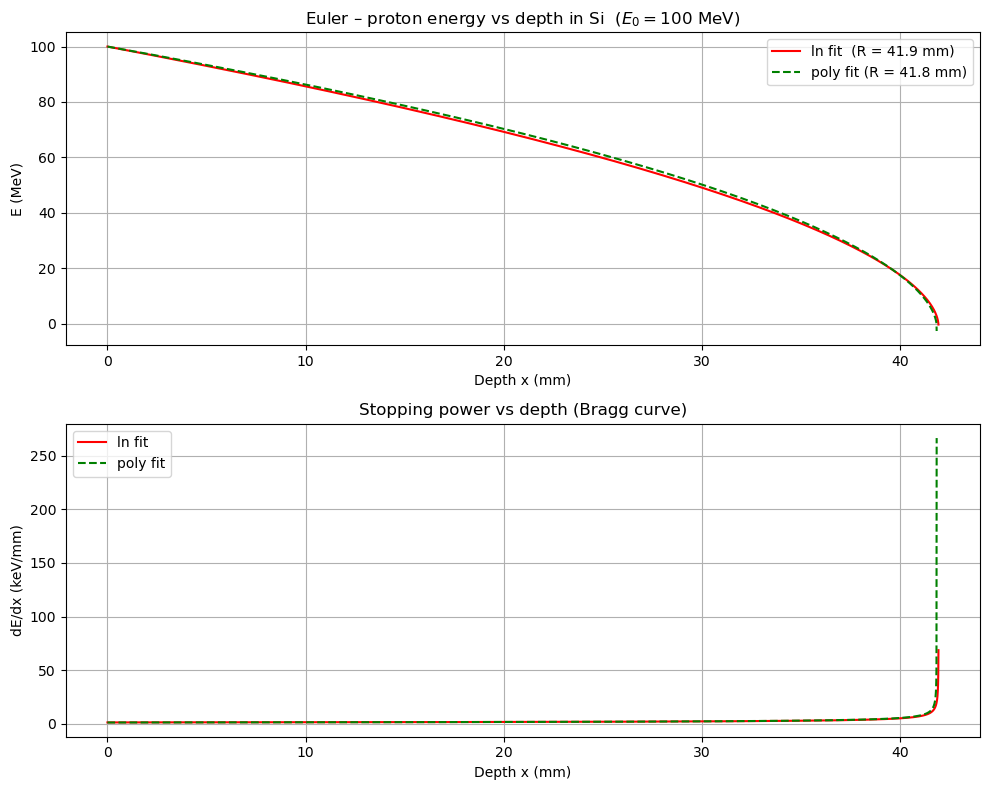

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

axs[0].plot(x_ln,   E_ln,   color='red',   label=f'ln fit  (R = {x_ln[-1]:.1f} mm)')
axs[0].plot(x_poly, E_poly, color='green', label=f'poly fit (R = {x_poly[-1]:.1f} mm)', linestyle='--')
axs[0].set_xlabel('Depth x (mm)')
axs[0].set_ylabel('E (MeV)')
axs[0].set_title(r'Euler – proton energy vs depth in Si  ($E_0 = 100$ MeV)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(x_ln[:-1],   dEdx_ln,   color='red',   label='ln fit')
axs[1].plot(x_poly[:-1], dEdx_poly, color='green', label='poly fit', linestyle='--')
axs[1].set_xlabel('Depth x (mm)')
axs[1].set_ylabel('dE/dx (keV/mm)')
axs[1].set_title('Stopping power vs depth (Bragg curve)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

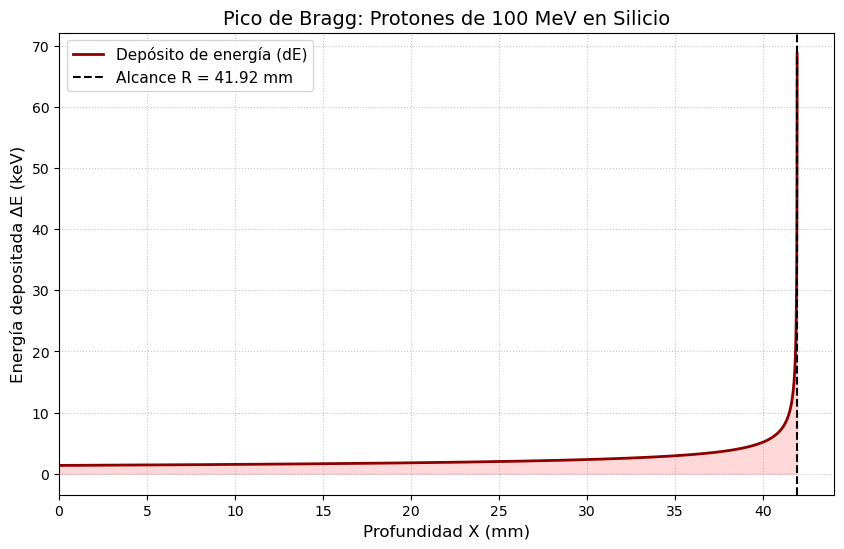

Alcance calculado: 41.92 mm


In [8]:
xs, dEs = x_ln[:-1], dEdx_ln

plt.figure(figsize=(10, 6))
plt.plot(xs, dEs, color='darkred', linewidth=2, label='Depósito de energía (dE)')
plt.fill_between(xs, dEs, color='red', alpha=0.15)

alcance_final = xs[-1]
plt.axvline(alcance_final, color='black', linestyle='--', label=f'Alcance R = {round(alcance_final, 3)} mm')

plt.title('Pico de Bragg: Protones de 100 MeV en Silicio', fontsize=14)
plt.xlabel('Profundidad X (mm)', fontsize=12)
plt.ylabel('Energía depositada ΔE (keV)', fontsize=12)
plt.xlim(0, alcance_final * 1.05)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.show()

print(f"Alcance calculado: {round(alcance_final, 4)} mm")

La gráfica muestra ΔE (energía depositada por paso de 0.001 mm) en función de la profundidad X. Lo que se observa es lo siguiente:
Al principio del recorrido (protón con 100 MeV), la pérdida de energía por paso es muy pequeña y casi constante — el protón es rápido y el stopping power es bajo. A medida que el protón va frenando y su energía disminuye, la pérdida de energía por paso aumenta progresivamente, cada vez más rápido.
Al final del recorrido se produce el Pico de Bragg: la pérdida de energía por unidad de longitud es máxima justo antes de que el protón se detenga completamente. Físicamente esto se entiende porque, a velocidades bajas (energías bajas), la interacción coulombiana con los electrones del material es más eficiente — el protón "tarda más" junto a cada electrón y le transfiere más energía.
Esto tiene una consecuencia muy práctica en radioterapia: los protones depositan la mayor parte de su energía en una zona muy localizada al final del recorrido, dañando selectivamente el tumor y protegiendo el tejido sano circundante.

# referencias

[1] J. B. Marion and F. C. Young, Nuclear Reaction Analysis: Graphs and Tables. North-Holland Publishing Company, 1968.